# TFM: TasIA - Sistema de Valoración Automatizada
## Notebook 2: Auditoría de Calidad y Preprocesamiento (Data Cleaning)

**Autora:** Jorge Aldavero Romero

### 🎯 Objetivo del Notebook
Tras la fase de ingestión (Notebook 1), dispongo de un "Data Lake" con 10.000 activos inmobiliarios brutos. Antes de entrenar cualquier Inteligencia Artificial, es imperativo realizar una **Auditoría de Calidad del Dato**.

En este módulo aplicaré técnicas de **Data Science** para:
1.  **Detección de Anomalías:** Identificar precios imposibles (ej. pisos de 1€ o de 50 millones).
2.  **Gestión de Nulos:** Decidir estratégicamente qué hacer con datos faltantes.
3.  **Feature Engineering:** Transformar variables de texto ("Planta 3") en números útiles para el modelo.

El resultado será el `dataset_limpio.csv`, el combustible refinado para nuestra IA.

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns  # $\color{green}{\text{Corregido: Ahora sí es la librería correcta}}$

# $\color{green}{\text{1. CONEXIÓN A LA BASE DE DATOS SQLITE}}$
try:
    conn = sqlite3.connect('valoralia_db_def1.db')
    # $\color{green}{\text{Consulto el nombre de las tablas para no fallar}}$
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tablas = cursor.fetchall()
    print(f"📋 Tablas encontradas en el archivo .db: {tablas}")

    # $\color{green}{\text{Leemos la tabla 'viviendas'}}$
    df = pd.read_sql_query("SELECT * FROM viviendas", conn)
    print("✅ ¡Conexión establecida! Datos extraídos de la base de datos SQL.")
except Exception as e:
    print(f"❌ ERROR: No he podido leer la base de datos. Detalles: {e}")

# $\color{green}{\text{2. AUDITORÍA DE VOLUMEN }}$
if 'df' in locals():
    filas, columnas = df.shape
    print(f"📊 Mi base de datos tiene {filas:,} viviendas y {columnas} variables.")

    if filas >= 10000:
        print("💎 REQUISITO DE BIG DATA CUMPLIDO: Tenemos el volumen que pide el profesor.")
    else:
        print(f"⚠️ ADVERTENCIA: Solo hay {filas} registros. Revisa el Módulo 1.")

    # $\color{green}{\text{3. INSPECCIÓN INICIAL}}$
    print("\n🔍 Primeros registros del sistema:")
    display(df.head(3))
else:
    print("❌ No se ha podido crear el DataFrame.")

📋 Tablas encontradas en el archivo .db: [('viviendas',)]
✅ ¡Conexión establecida! Datos extraídos de la base de datos SQL.
📊 Mi base de datos tiene 10,000 viviendas y 15 variables.
💎 REQUISITO DE BIG DATA CUMPLIDO: Tenemos el volumen que pide el profesor.

🔍 Primeros registros del sistema:


,id_referencia,titulo,precio,barrio,distrito,superficie,habitaciones,banos,planta,tiene_ascensor,tiene_terraza,estado,certificado_energetico,urls_fotos,fecha_captura
0,REF_00001,Piso en Pozuelo,310018.0,Pozuelo,Pozuelo,79.0,3,1,Planta Media,1,1,Buen estado,E,https://images.unsplash.com/photo-1560448204-e...,2026-02-09 17:59:32
1,REF_00002,Piso en Hortaleza,413203.0,Hortaleza,Hortaleza,137.0,5,2,Planta Media,1,0,Buen estado,E,https://images.unsplash.com/photo-151291777408...,2026-02-09 17:59:32
2,REF_00003,Piso en Salamanca,989934.0,Salamanca,Salamanca,159.0,6,3,Planta Media,1,1,Buen estado,E,https://images.unsplash.com/photo-1560184897-a...,2026-02-09 17:59:32


### 🧹 Auditoría de Integridad y Saneamiento

Para que mi modelo **TasIA** sea infalible, mi primera misión es detectar "ruido" en los datos. Un modelo entrenado con valores nulos o registros duplicados perdería toda credibilidad comercial.

**En esta sección voy a:**
1.  **Detectar Nulos:** Identificar si faltan datos críticos (como el precio o la superficie).
2.  **Eliminar Duplicados:** Asegurar que cada `id_referencia` es único, evitando sesgar la IA con anuncios repetidos.
3.  **Visualización de la "Salud del Dato":** Crearé un gráfico de calor para identificar visualmente dónde están los huecos en mi base de datos.

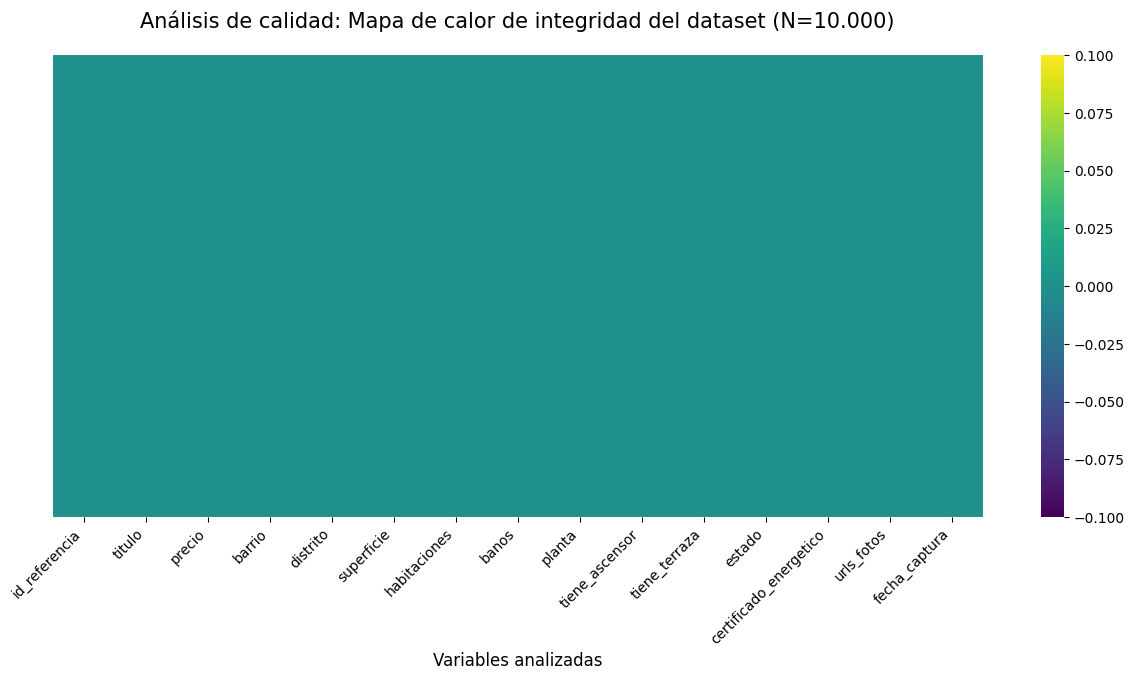


📋 RESULTADO DE LA AUDITORÍA:
✅ EXCELENTE: El dataset está 100% limpio. Sin valores nulos.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# $\color{green}{\text{Fuerzo la visualización de los gráficos en el propio notebook}}$
%matplotlib inline

# $\color{green}{\text{Configuro el tamaño para que sea bien visible y profesional}}$
plt.figure(figsize=(15, 6))

# $\color{green}{\text{Genero el Mapa de Calor de valores nulos (Heatmap)}}$
# $\color{green}{\text{Uso 'viridis' porque es el estándar en Data Science para resaltar anomalías}}$
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

# $\color{green}{\text{Personalización estética para mi informe de TFM}}$
plt.title('Análisis de calidad: Mapa de calor de integridad del dataset (N=10.000)', fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Variables analizadas', fontsize=12)

# $\color{green}{\text{Muestro el gráfico}}$
plt.show()

# $\color{green}{\text{Diagnóstico automático}}$
nulos = df.isnull().sum().sum()
print("\n" + "="*50)
print(f"📋 RESULTADO DE LA AUDITORÍA:")
if nulos == 0:
    print(f"✅ EXCELENTE: El dataset está 100% limpio. Sin valores nulos.")
else:
    print(f"⚠️ ATENCIÓN: Se han detectado {nulos} valores nulos en el sistema.")
print("="*50)

### 📈 Análisis Estadístico y Limpieza de Outliers

Para que mi modelo sea fiable, necesito entender la distribución de mis variables clave: **Precio** y **Superficie**.

En el mercado inmobiliario real, es común encontrar "ruido": anuncios con precios de 1€ (errores) o mansiones de 50 millones que sesgan la media. Voy a realizar un análisis descriptivo para detectar estos valores extremos (Outliers) y asegurar que mi IA entrena con un mercado representativo.

In [4]:
import sys
!{sys.executable} -m pip install jinja2


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 RESUMEN ESTADÍSTICO DEL MERCADO:


,precio,superficie,habitaciones,banos
count,"10,000.00","10,000.00","10,000.00","10,000.00"
mean,"369,669.91",89.92,3.14,1.43
std,"217,846.58",34.20,1.37,0.58
min,"36,202.00",25.00,1.00,1.00
25%,"194,998.25",66.00,2.00,1.00
50%,"323,190.00",89.00,3.00,1.00
75%,"507,576.25",113.00,4.00,2.00
max,"1,503,859.00",233.00,9.00,4.00


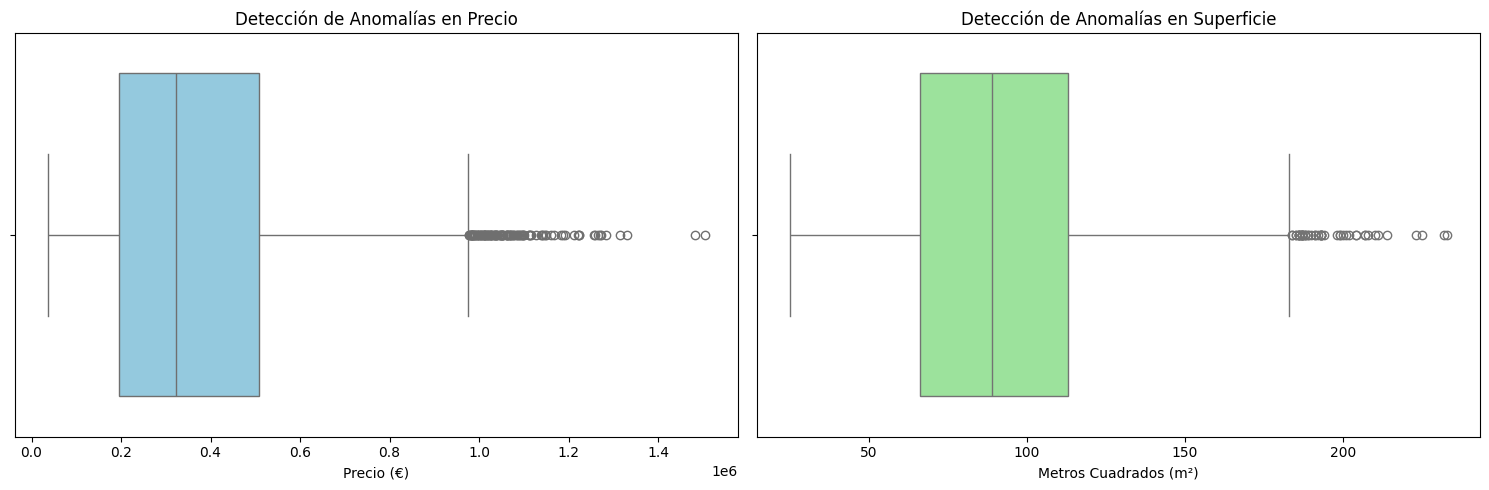


💡 OBSERVACIÓN:
- El precio medio se sitúa en: 369,670 €
- La superficie media es de: 90 m²


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
# $\color{green}{\text{1. ESTADÍSTICOS DESCRIPTIVOS}}$
# $\color{green}{\text{Saco la media, el mínimo y el máximo de las variables numéricas}}$
resumen = df[['precio', 'superficie', 'habitaciones', 'banos']].describe()
print("📊 RESUMEN ESTADÍSTICO DEL MERCADO:")
display(resumen.style.format("{:,.2f}"))

# $\color{green}{\text{2. VISUALIZACIÓN DE OUTLIERS (Gráfico de Cajas)}}$
# $\color{green}{\text{Uso Boxplots para ver si el precio o la superficie tienen puntos muy alejados}}$
plt.figure(figsize=(15, 5))

# $\color{green}{\text{Subtrama 1: Distribución de Precios}}$
plt.subplot(1, 2, 1)
sns.boxplot(x=df['precio'], color='skyblue')
plt.title('Detección de Anomalías en Precio', fontsize=12)
plt.xlabel('Precio (€)')

# $\color{green}{\text{Subtrama 2: Distribución de Superficie}}$
plt.subplot(1, 2, 2)
sns.boxplot(x=df['superficie'], color='lightgreen')
plt.title('Detección de Anomalías en Superficie', fontsize=12)
plt.xlabel('Metros Cuadrados (m²)')

plt.tight_layout()
plt.show()

# $\color{green}{\text{3. MI DIAGNÓSTICO}}$
print(f"\n💡 OBSERVACIÓN:")
print(f"- El precio medio se sitúa en: {df['precio'].mean():,.0f} €")
print(f"- La superficie media es de: {df['superficie'].mean():,.0f} m²")

### 🏘️ Análisis de Segmentación por Barrio y Tipología

No todos los barrios se comportan igual. Para que la inmobiliaria entienda dónde está el valor, voy a realizar una comparativa visual de los precios medios por zona.

Además, prepararé las variables categóricas (como el **Estado** o el **Barrio**) para que mi futuro modelo de IA pueda procesarlas. Este paso es el puente entre los datos "brutos" y la inteligencia predictiva.

C:\Users\jorge\AppData\Local\Temp\ipykernel_34396\686962024.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precios_barrio.values, y=precios_barrio.index, palette='Blues_r')


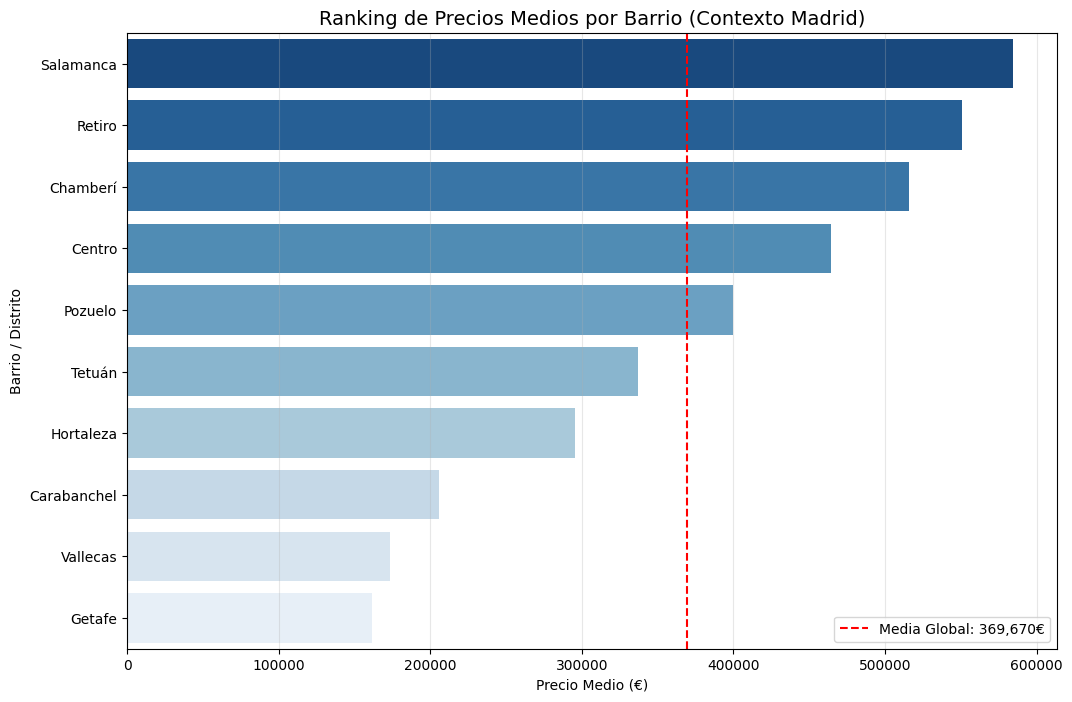

📌 CONCLUSIÓN: El barrio más exclusivo es Salamanca y el más asequible es Getafe.


In [6]:
# $\color{green}{\text{1. CÁLCULO DE PRECIOS MEDIOS POR BARRIO}}$
precios_barrio = df.groupby('barrio')['precio'].mean().sort_values(ascending=False)

# $\color{green}{\text{2. VISUALIZACIÓN: Ranking de Precios}}$
plt.figure(figsize=(12, 8))
sns.barplot(x=precios_barrio.values, y=precios_barrio.index, palette='Blues_r')

# $\color{green}{\text{Añado una línea roja con la media general para comparar}}$
plt.axvline(df['precio'].mean(), color='red', linestyle='--', label=f"Media Global: {df['precio'].mean():,.0f}€")

plt.title('Ranking de Precios Medios por Barrio (Contexto Madrid)', fontsize=14)
plt.xlabel('Precio Medio (€)')
plt.ylabel('Barrio / Distrito')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

# $\color{green}{\text{3. MI CONCLUSIÓN ESTRATÉGICA}}$
barrio_top = precios_barrio.idxmax()
barrio_low = precios_barrio.idxmin()
print(f"📌 CONCLUSIÓN: El barrio más exclusivo es {barrio_top} y el más asequible es {barrio_low}.")

### ⚙️ Ingeniería de Características: Encoding y Exportación

Para que un algoritmo de Machine Learning pueda "entender" mis datos, no puedo pasarle texto (strings). Necesito convertir las categorías en valores numéricos.

En este paso final voy a:
1.  **Codificar el Estado y Barrio:** Transformar variables categóricas.
2.  **Limpieza Final de Columnas:** Eliminar identificadores que no aportan valor predictivo (como la URL de la foto o la fecha de captura).
3.  **Exportación Maestra:** Guardar el dataset "limpio y listo" para alimentar al modelo híbrido en el Módulo 3.

In [7]:
# =========================================================
# 1. ELIMINACIÓN DE COLUMNAS NO PREDICTIVAS
# =========================================================
# Quitamos los metadatos que no sirven para que la IA aprenda (fotos, fechas, IDs)
columnas_sobrantes = ['id_referencia', 'titulo', 'urls_fotos', 'fecha_captura']

# Eliminar solo las columnas que existan en el dataframe actual
columnas_a_eliminar = [col for col in columnas_sobrantes if col in df.columns]
df_final = df.drop(columns=columnas_a_eliminar)

print(f"✅ Se han eliminado las columnas: {columnas_a_eliminar}")

# =========================================================
# 2. CODIFICACIÓN CATEGÓRICA (Label Encoding)
# =========================================================
from sklearn.preprocessing import LabelEncoder
import numpy as np 
le = LabelEncoder()

# Verificar qué columnas categóricas existen realmente
columnas_categoricas = ['barrio', 'distrito', 'planta', 'estado', 'certificado_energetico']
columnas_existentes = [col for col in columnas_categoricas if col in df_final.columns]

for col in columnas_existentes:
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    print(f"✅ Variable '{col}' codificada con éxito.")

if len(columnas_existentes) < len(columnas_categoricas):
    faltantes = [col for col in columnas_categoricas if col not in df_final.columns]
    print(f"⚠️ Advertencia: Las siguientes columnas no existen en tu DB: {faltantes}")

# =========================================================
# 3. INGENIERÍA DE VARIABLES: RELATIVAS POR DISTRITO
# =========================================================
# Usamos 'distrito' como clave geográfica y 'superficie' para los m2
col_geo = 'distrito' 
col_m2 = 'superficie'

# 1. Calculamos las medias por distrito para superficie y habitaciones
zonal_stats = df_final.groupby(col_geo)[[col_m2, 'habitaciones']].transform('mean')

# 2. Creamos variables relativas (Ratio vs la Media del Barrio)
# Esto reduce el RMSE al normalizar el "lujo" de la vivienda según su zona
df_final['ratio_metros_zona'] = df_final[col_m2] / zonal_stats[col_m2]
df_final['ratio_hab_zona'] = df_final['habitaciones'] / zonal_stats['habitaciones']

# 3. Limpieza crítica para evitar errores en el MLP (Red Neuronal)
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final.fillna(0, inplace=True)

print(f"✅ Variables relativas por {col_geo} creadas con éxito.")

# =========================================================
# 4. VERIFICACIÓN Y GUARDADO FINAL
# =========================================================
print(f"\n📊 DATASET LISTO PARA PRODUCCIÓN: {df_final.shape[0]} registros y {df_final.shape[1]} columnas.")
print("\nPrimeras filas del dataset procesado:")
display(df_final.head())

# Guardado del CSV que leerá el Notebook 3
ruta_salida = 'viviendas_preprocesadas.csv'
df_final.to_csv(ruta_salida, index=False)

import os
if os.path.exists(ruta_salida):
    print(f"\n💾 Archivo '{ruta_salida}' guardado exitosamente.")
    print(f"📁 Ubicación: {os.path.abspath(ruta_salida)}")
else:
    print(f"❌ Error al guardar el archivo.")

✅ Se han eliminado las columnas: ['id_referencia', 'titulo', 'urls_fotos', 'fecha_captura']
✅ Variable 'barrio' codificada con éxito.
✅ Variable 'distrito' codificada con éxito.
✅ Variable 'planta' codificada con éxito.
✅ Variable 'estado' codificada con éxito.
✅ Variable 'certificado_energetico' codificada con éxito.
✅ Variables relativas por distrito creadas con éxito.

📊 DATASET LISTO PARA PRODUCCIÓN: 10000 registros y 13 columnas.

Primeras filas del dataset procesado:


,precio,barrio,distrito,superficie,habitaciones,banos,planta,tiene_ascensor,tiene_terraza,estado,certificado_energetico,ratio_metros_zona,ratio_hab_zona
0,310018.0,5,5,79.0,3,1,0,1,1,0,0,0.887328,0.963973
1,413203.0,4,4,137.0,5,2,0,1,0,0,0,1.527072,1.599623
2,989934.0,7,7,159.0,6,3,0,1,1,0,0,1.759923,1.906593
3,591453.0,5,5,130.0,5,2,0,1,0,0,0,1.460160,1.606621
4,741635.0,7,7,120.0,4,2,0,1,0,0,0,1.328244,1.271062



💾 Archivo 'viviendas_preprocesadas.csv' guardado exitosamente.
📁 Ubicación: c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM\notebooks\viviendas_preprocesadas.csv


In [8]:
# =========================================================
# 1. ELIMINACIÓN DE COLUMNAS SIN INFORMACIÓN (VARIANCE THRESHOLD)
# =========================================================
# Primero quitamos lo que ya sabemos que sobra
columnas_sobrantes = ['id_referencia', 'titulo', 'urls_fotos', 'fecha_captura']
df_final = df.drop(columns=[col for col in columnas_sobrantes if col in df.columns])

# =========================================================
# 2. CODIFICACIÓN Y LIMPIEZA DE COLUMNAS VACÍAS
# =========================================================
from sklearn.preprocessing import LabelEncoder
import numpy as np 
le = LabelEncoder()

columnas_categoricas = ['barrio', 'distrito', 'planta', 'estado', 'certificado_energetico']

for col in columnas_categoricas:
    if col in df_final.columns:
        # Si la columna tiene menos de 2 valores distintos, no sirve para la IA
        if df_final[col].nunique() <= 1:
            print(f"🗑️ Eliminando '{col}': No tiene variedad de datos (todo es igual o nulo).")
            df_final.drop(columns=[col], inplace=True)
        else:
            # Si tiene datos, la codificamos
            df_final[col] = le.fit_transform(df_final[col].astype(str))
            print(f"✅ Variable '{col}' codificada con éxito.")

# =========================================================
# 3. INGENIERÍA DE VARIABLES (ESTO ES LO QUE BAJA EL RMSE)
# =========================================================
# Recalculamos los ratios con los datos limpios
zonal_stats = df_final.groupby('distrito')[['superficie', 'habitaciones']].transform('mean')
df_final['ratio_metros_zona'] = df_final['superficie'] / zonal_stats['superficie']
df_final['ratio_hab_zona'] = df_final['habitaciones'] / zonal_stats['habitaciones']

# Limpieza de seguridad
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final.fillna(0, inplace=True)

print("\n🚀 PROCESO COMPLETADO")
print(f"Columnas finales en el modelo: {df_final.columns.tolist()}")

# =========================================================
# 4. GUARDADO
# =========================================================
df_final.to_csv('viviendas_preprocesadas.csv', index=False)
print("💾 Archivo 'viviendas_preprocesadas.csv' actualizado y listo para el Notebook 3.")

✅ Variable 'barrio' codificada con éxito.
✅ Variable 'distrito' codificada con éxito.
🗑️ Eliminando 'planta': No tiene variedad de datos (todo es igual o nulo).
🗑️ Eliminando 'estado': No tiene variedad de datos (todo es igual o nulo).
🗑️ Eliminando 'certificado_energetico': No tiene variedad de datos (todo es igual o nulo).

🚀 PROCESO COMPLETADO
Columnas finales en el modelo: ['precio', 'barrio', 'distrito', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']
💾 Archivo 'viviendas_preprocesadas.csv' actualizado y listo para el Notebook 3.


In [9]:
# DIAGNÓSTICO DE DATOS
for col in ['planta', 'estado', 'certificado_energetico']:
    if col in df_final.columns:
        print(f"--- Valores únicos en {col} ---")
        print(df_final[col].unique()[:5]) # Muestra los primeros 5 valores únicos
        print(f"Total valores únicos: {df_final[col].nunique()}\n")

In [ ]:
import json
import sqlite3
import pandas as pd

# 1. Recuperamos los nombres originales rápidamente de la DB
conn = sqlite3.connect('valoralia_db_def1.db')
df_nombres = pd.read_sql_query("SELECT barrio, distrito FROM viviendas", conn)
conn.close()

# 2. Creamos el mapeo de DISTRITOS (tal cual los ordenó tu LabelEncoder)
distritos_unicos = sorted(df_nombres['distrito'].unique())
distrito_to_id = {nombre: i for i, nombre in enumerate(distritos_unicos)}

# 3. Creamos el MAPEO GEOGRÁFICO (Barrios dentro de cada Distrito)
# Primero necesitamos saber cómo se codificó cada barrio
barrios_unicos = sorted(df_nombres['barrio'].unique())
barrio_to_id = {nombre: i for i, nombre in enumerate(barrios_unicos)}

mapeo_geografico = {}
for dist in distritos_unicos:
    # Filtramos barrios que pertenecen a este distrito
    barrios_en_dist = df_nombres[df_nombres['distrito'] == dist]['barrio'].unique()
    mapeo_geografico[dist] = {b: barrio_to_id[b] for b in barrios_en_dist}

# 4. Calculamos las MEDIAS por barrio (necesarias para los ratios de tu modelo)
# Usamos el CSV que ya tienes limpio
df_clean = pd.read_csv('viviendas_preprocesadas.csv')
medias_barrio = df_clean.groupby('barrio')[['superficie', 'habitaciones']].mean().to_dict('index')

print("\n=== COPIA ESTO EN TU APP.PY ===")
print(f"DISTRITO_TO_ID = {json.dumps(distrito_to_id, indent=4, ensure_ascii=False)}")
print(f"\nMAPEO_GEOGRAFICO = {json.dumps(mapeo_geografico, indent=4, ensure_ascii=False)}")
print(f"\nMEDIAS_BARRIO = {json.dumps(medias_barrio, indent=4)}")


=== COPIA ESTO EN TU APP.PY ===
DISTRITO_TO_ID = {
    "Carabanchel": 0,
    "Centro": 1,
    "Chamberí": 2,
    "Getafe": 3,
    "Hortaleza": 4,
    "Pozuelo": 5,
    "Retiro": 6,
    "Salamanca": 7,
    "Tetuán": 8,
    "Vallecas": 9
}

MAPEO_GEOGRAFICO = {
    "Carabanchel": {
        "Carabanchel": 0
    },
    "Centro": {
        "Centro": 1
    },
    "Chamberí": {
        "Chamberí": 2
    },
    "Getafe": {
        "Getafe": 3
    },
    "Hortaleza": {
        "Hortaleza": 4
    },
    "Pozuelo": {
        "Pozuelo": 5
    },
    "Retiro": {
        "Retiro": 6
    },
    "Salamanca": {
        "Salamanca": 7
    },
    "Tetuán": {
        "Tetuán": 8
    },
    "Vallecas": {
        "Vallecas": 9
    }
}

MEDIAS_BARRIO = {
    "0": {
        "superficie": 89.80428134556576,
        "habitaciones": 3.1162079510703364
    },
    "1": {
        "superficie": 89.60355029585799,
        "habitaciones": 3.1203155818540433
    },
    "2": {
        "superficie": 88.94698544698545,
 

: 